# Exploratory Data Analysis (EDA)
This notebook explores the Steam player dataset to understand features, distributions, and the target variable `churn`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)


## 1. Data Loading and Overview
Let's load our processed player dataset.


In [2]:
df = pd.read_csv('../data/processed/player_data.csv')
display(df.head())
print("\nDataset Info:")
display(df.info())


,steam_id,last_logoff,personastate,total_playtime,game_count,recent_playtime,churn,engagement_ratio,high_value_player,avg_playtime_per_game
0,76561197960265731,NaN,0.0,738189,413,5033,0,0.006818,1,1783.065217
1,76561197960265754,NaN,3.0,293311,543,13,0,0.000044,1,539.174632
2,76561197960270862,NaN,3.0,764760,750,31,0,0.000041,1,1018.322237
3,76561197960272940,NaN,0.0,186130,302,0,1,0.000000,1,614.290429
4,76561197960273963,NaN,0.0,520713,996,2587,0,0.004968,1,522.279840



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 486 entries, 0 to 485
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   steam_id               486 non-null    int64  
 1   last_logoff            0 non-null      float64
 2   personastate           486 non-null    float64
 3   total_playtime         486 non-null    int64  
 4   game_count             486 non-null    int64  
 5   recent_playtime        486 non-null    int64  
 6   churn                  486 non-null    int64  
 7   engagement_ratio       486 non-null    float64
 8   high_value_player      486 non-null    int64  
 9   avg_playtime_per_game  486 non-null    float64
dtypes: float64(4), int64(6)
memory usage: 38.1 KB


None

## 2. Target Variable (Churn) Analysis
Let's look at the class balance for our target variable.


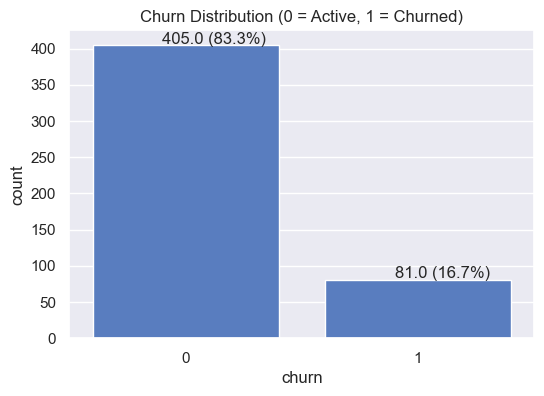

In [3]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='churn')
plt.title('Churn Distribution (0 = Active, 1 = Churned)')
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({p.get_height()/len(df)*100:.1f}%)', (p.get_x() + 0.3, p.get_height() + 2))
plt.show()


## 3. Feature Distributions
Let's analyze numerical features like `total_playtime`, `recent_playtime`, and `engagement_ratio`.


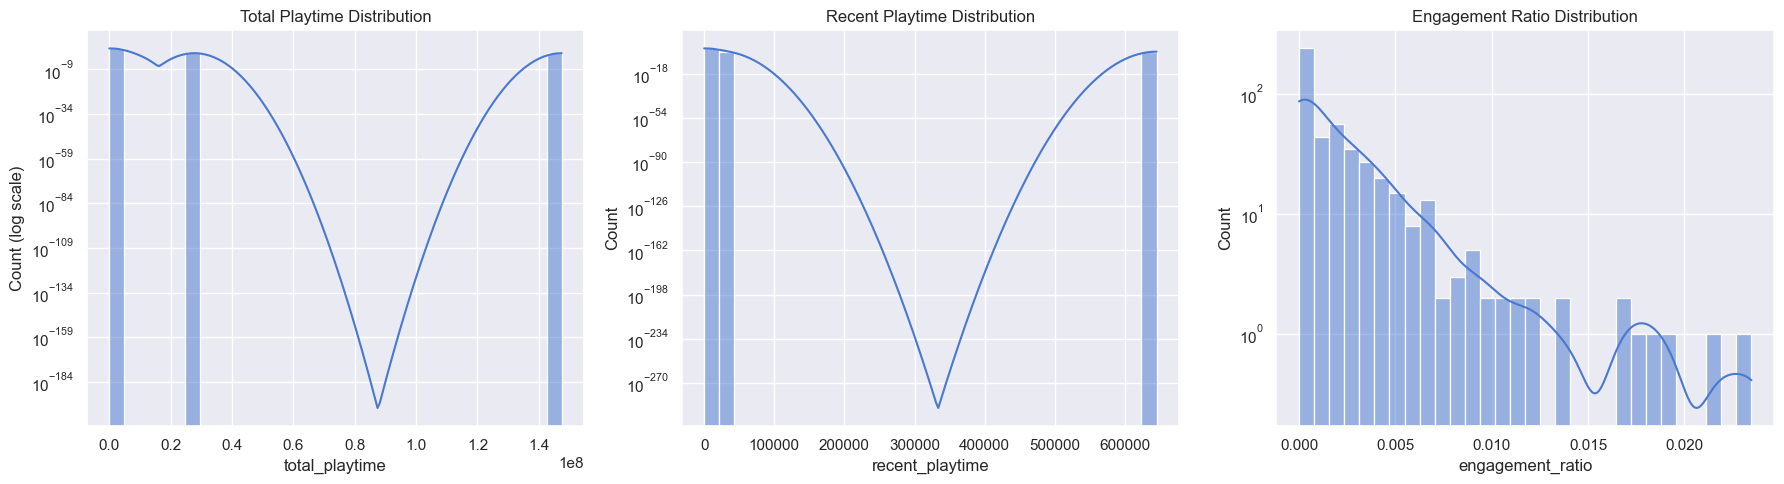

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['total_playtime'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Total Playtime Distribution')
axes[0].set_yscale('log')
axes[0].set_ylabel('Count (log scale)')

sns.histplot(df['recent_playtime'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Recent Playtime Distribution')
axes[1].set_yscale('log')

sns.histplot(df['engagement_ratio'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Engagement Ratio Distribution')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()


## 4. Bivariate Analysis
How do different features relate to churn?


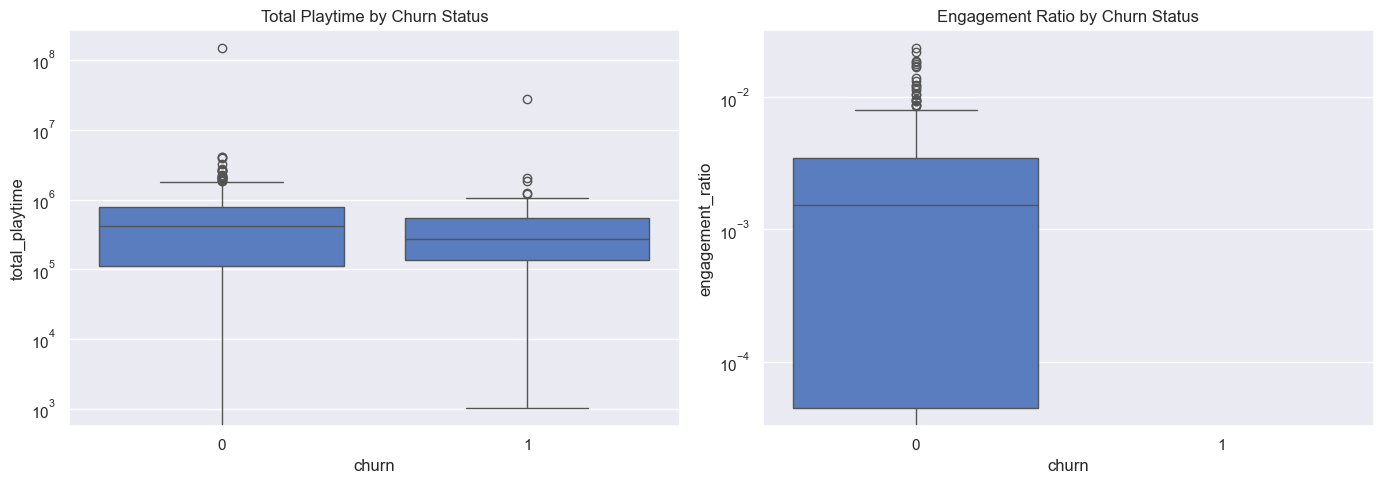

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='churn', y='total_playtime', ax=axes[0])
axes[0].set_title('Total Playtime by Churn Status')
axes[0].set_yscale('log')

sns.boxplot(data=df, x='churn', y='engagement_ratio', ax=axes[1])
axes[1].set_title('Engagement Ratio by Churn Status')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()


## 5. Correlation Analysis
Let's check the correlation between variables to identify multicollinearity or predictive features.


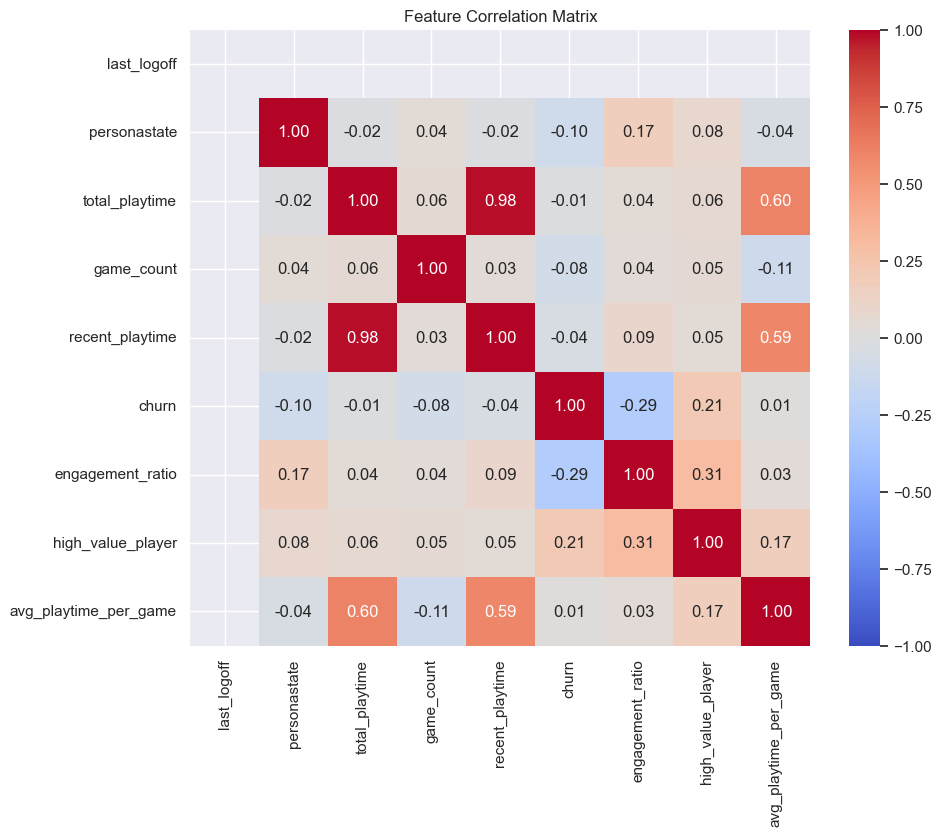

In [6]:
corr = df.drop(columns=['steam_id']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.show()
